## **Importing Dataset from Kaggle**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jivanshraghuvanshi15","key":"e9742837274ddca0c09a7cd45b6c4d7b"}'}

In [ ]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d sshikamaru/fruit-recognition
!unzip fruit-recognition.zip

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation,
                                     RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomBrightness, Rescaling)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import ResNet50, MobileNetV2

### **Content of dataset**

In [4]:
total_labels=0
for i in os.listdir("/content/train/train"):
    print(i)
    total_labels+=1
print(f"Total classes: {total_labels}")

Apple Braeburn
Pear
Avocado
Plum
Pomegranate
Blueberry
Passion Fruit
Potato Red
Cucumber Ripe
Clementine
Watermelon
Corn
Mango
Strawberry
Cantaloupe
Pepper Red
Limes
Pepper Green
Raspberry
Tomato
Peach
Cherry
Onion White
Kiwi
Cactus fruit
Papaya
Grape Blue
Orange
Lemon
Apricot
Pineapple
Banana
Apple Granny Smith
Total classes: 33


## **Splitting into Training and Validation data**

In [5]:
train_dir="/content/train/train"
train_ds=image_dataset_from_directory(
    train_dir,
    subset="training",
    validation_split=0.2,
    seed=42,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    image_size=(224,224),
    batch_size=32,
    shuffle=True)
print(train_ds.class_names)

val_ds=image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    image_size=(224,224),
    batch_size=32,
    shuffle=True)

Found 16854 files belonging to 33 classes.
Using 13484 files for training.
['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Found 16854 files belonging to 33 classes.
Using 3370 files for validation.


### **Tuning for faster loading**

In [6]:
auto=tf.data.AUTOTUNE
train_ds=train_ds.prefetch(auto)
val_ds=val_ds.prefetch(auto)

In [7]:
data_augmentation=Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
    RandomContrast(0.2),
    RandomBrightness(0.2),])
normalize=Rescaling(1./255)

train_ds=train_ds.map(
    lambda x, y: (normalize(data_augmentation(x, training=True)), y),
    num_parallel_calls=auto)

val_ds=val_ds.map(lambda x, y: (normalize(x), y))

In [8]:
for image, label in train_ds.take(1):
    print(f"Image batch shape:{image.shape}")

Image batch shape:(32, 224, 224, 3)


### **1. RESNET ARCHITECTURE**

In [15]:
resnet_model=ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3))

In [ ]:
resnet_model.trainable = False
x=resnet_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(512, activation='relu')(x)
x=Dropout(0.5)(x)
output=Dense(33, activation='softmax')(x)

resnet_model=Model(inputs=resnet_model.input, outputs=output)

resnet_model.summary()

### **Compiling model**

In [17]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"])

lr_reducer=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-6),

early_stop=EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint=ModelCheckpoint(
    'best_resnet.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

### **Training**

In [ ]:
# history=resnet_model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=15,
#     callbacks=[lr_reducer,early_stop,checkpoint])

In [ ]:
# test_loss,test_acc=resnet_model.evaluate(train_ds, verbose=1)
# print(f'Test Accuracy: {test_acc:.4f}')

### **1. MobileNetV2 ARCHITECTURE**

In [20]:
inputs=Input(shape=(224, 224, 3))
x=Rescaling(scale=2.0, offset=-1.0)(inputs)

mobilenet_model=MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_tensor=x)

/tmp/ipython-input-2513514259.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_model=MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [31]:
x=mobilenet_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(256, activation='relu')(x)
x=Dropout(0.5)(x)
outputs=Dense(33, activation='softmax')(x)

mobile_model=Model(inputs, outputs)

In [32]:
mobile_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"])

lr_reducer=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-6),

early_stop=EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint=ModelCheckpoint(
    'best_resnet.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

In [33]:
history=mobile_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[lr_reducer,early_stop,checkpoint])

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7764 - loss: 0.8262
Epoch 1: val_accuracy improved from -inf to 0.30801, saving model to best_resnet.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 248s 448ms/step - accuracy: 0.7767 - loss: 0.8252 - val_accuracy: 0.3080 - val_loss: 8.6318 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9517 - loss: 0.1965
Epoch 2: val_accuracy did not improve from 0.30801
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 330ms/step - accuracy: 0.9517 - loss: 0.1964 - val_accuracy: 0.2045 - val_loss: 8.7490 - learning_rate: 0.0010
Epoch 3/20
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9703 - loss: 0.1090
Epoch 3: val_accuracy improved from 0.30801 to 0.34421, saving model to best_resnet.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 141s 332ms/step - accuracy: 0.9703 - loss: 0.1089 - val_accuracy: 0.3442 - val_loss: 4.2951 - learning_rate: 0.0010
Epoch 4/20
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9795 

### **Visualisation of accuracy and loss per epoch**

In [34]:
test_loss,test_acc=mobile_model.evaluate(train_ds, verbose=1)
print(f'Test Accuracy: {test_acc:.4f}')

422/422 ━━━━━━━━━━━━━━━━━━━━ 135s 319ms/step - accuracy: 0.9998 - loss: 4.6370e-04
Test Accuracy: 0.9996


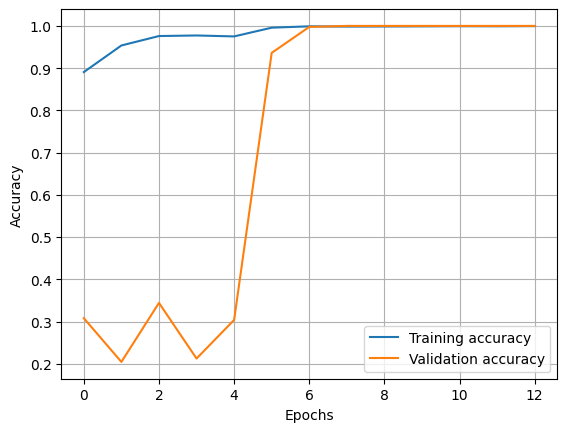

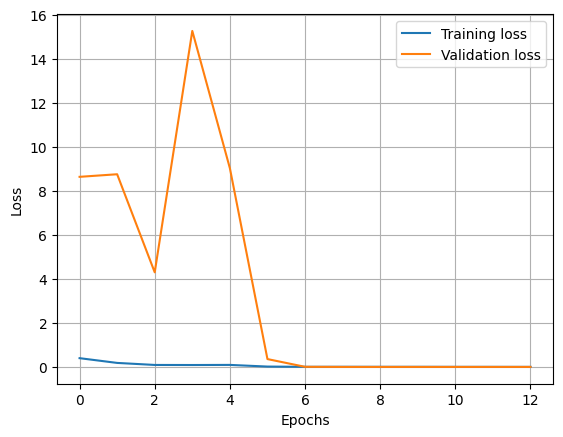

In [35]:
plt.plot(history.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [38]:
# import os
# import shutil
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')
# drive_model_path = '/content/drive/MyDrive/saved_models/'
# os.makedirs(drive_model_path, exist_ok=True)

# shutil.copy('best_resnet.keras',
#             os.path.join(drive_model_path, 'best_resnet.keras'))

# print(f"'best_resnet.keras' has been copied to {drive_model_path}")

Mounted at /content/drive
'best_resnet.keras' has been copied to /content/drive/MyDrive/saved_models/
